# Testing for preprocessing image technique, etc

# All Libraries 

In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms
import insightface
from insightface.app import FaceAnalysis

print("All imports OK")
print("Torch:", torch.__version__)

c:\Users\user\Documents\GitHub\Anti-Spoofing-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK
Torch: 2.7.1+cu118


# Load Face Detector

In [3]:
# ── Cell 3: Load face detector (SCRFD via InsightFace) ────────────────────────
detector = FaceAnalysis(name='buffalo_sc', providers=['CPUExecutionProvider'])
detector.prepare(ctx_id=-1, det_size=(640, 640))
# buffalo_sc = SCRFD + ArcFace, lightweight, same family used in the challenge
print("Detector ready")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\user/.insightface\models\buffalo_sc\det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\user/.insightface\models\buffalo_sc\w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Detector ready


# Function to Show Image side by side

In [4]:
# ── Cell 4: Helper — show images side by side ─────────────────────────────────
def show_images(images: list, titles: list, figsize=(16, 4)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        # matplotlib expects RGB
        if isinstance(img, np.ndarray) and img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.shape[2] == 3 else img
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Face Detection

## Face Detection

Original shape: (1920, 1080, 3)


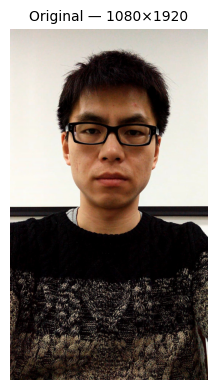

In [5]:
# ── Cell 5: Load a sample image ───────────────────────────────────────────────
# Replace this path with your actual image
IMAGE_PATH = r"C:\Users\user\Downloads\archive\Oulu-NPU\true\6_2_38_1_1.jpg"   # or any image you have

# Reading image
img_bgr = cv2.imread(IMAGE_PATH)
assert img_bgr is not None, f"Could not load image at {IMAGE_PATH}"

print(f"Original shape: {img_bgr.shape}")  # (H, W, 3)
show_images([img_bgr], [f"Original — {img_bgr.shape[1]}×{img_bgr.shape[0]}"])

c:\Users\user\Documents\GitHub\Anti-Spoofing-\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Faces detected: 1
  Face 0: bbox=[317 316 796 972], score=0.787


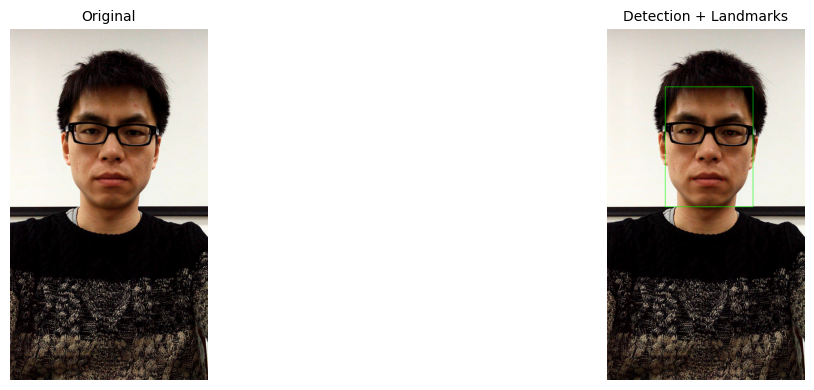

In [6]:
# ── Cell 6: Step 1 — Face Detection ───────────────────────────────────────────
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
# Using the 
faces = detector.get(img_rgb)

print(f"Faces detected: {len(faces)}")
for i, face in enumerate(faces):
    print(f"  Face {i}: bbox={face.bbox.astype(int)}, score={face.det_score:.3f}")

# Draw detections
vis = img_bgr.copy()
for face in faces:
    x1, y1, x2, y2 = face.bbox.astype(int)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Draw 5 landmarks (eyes, nose, mouth corners)
    for kp in face.kps.astype(int):
        cv2.circle(vis, tuple(kp), 3, (0, 0, 255), -1)

show_images([img_bgr, vis], ["Original", "Detection + Landmarks"])

## Crop Margin

In [7]:
faces

[{'bbox': array([317.97723, 316.2521 , 796.86163, 972.68317], dtype=float32),
  'kps': array([[442.16364, 563.5987 ],
         [670.381  , 567.42444],
         [551.9769 , 694.9927 ],
         [462.79807, 818.1046 ],
         [635.6915 , 821.93616]], dtype=float32),
  'det_score': np.float32(0.7865102),
  'embedding': array([-5.47366798e-01, -1.80871272e+00, -4.11893129e-01, -1.07191309e-01,
          1.21841145e+00,  9.43358660e-01,  1.14602000e-01,  1.67329025e+00,
         -1.36079311e+00,  8.28750253e-01, -4.58171695e-01, -5.15546203e-01,
          4.09825206e-01,  1.07427561e+00,  1.62198794e+00, -9.76879299e-01,
          1.25301331e-01,  3.47183943e-01, -1.41422033e-01,  3.51394713e-01,
         -5.46880782e-01,  4.94150519e-01, -7.50122964e-01,  5.73326886e-01,
         -5.66111207e-01,  2.91067421e-01, -5.60135365e-01, -1.56993687e+00,
          8.13218236e-01,  1.16887033e+00, -6.56270206e-01, -1.27647147e-01,
          4.37908709e-01, -2.65968978e-01, -1.14797318e+00,  1.130

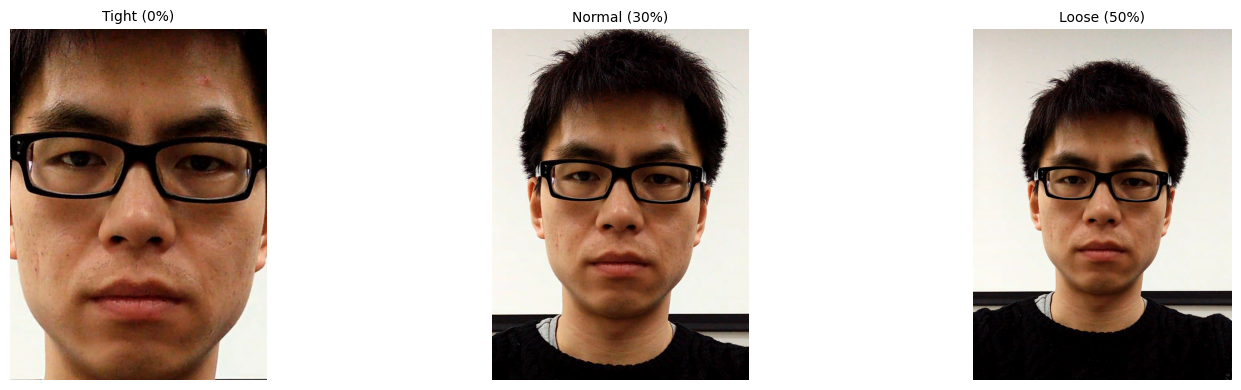

In [8]:
# ── Cell 7: Step 2 — Crop with margin ─────────────────────────────────────────
def crop_face(img, bbox, margin=0.3):
    """
    Expand bbox by `margin` fraction on each side.
    Clips to image boundaries — never goes out of bounds.
    """
    H, W = img.shape[:2]
    x1, y1, x2, y2 = bbox.astype(int)
    bw, bh = x2 - x1, y2 - y1

    x1 = max(0, int(x1 - bw * margin))
    y1 = max(0, int(y1 - bh * margin))
    x2 = min(W, int(x2 + bw * margin))
    y2 = min(H, int(y2 + bh * margin))

    return img[y1:y2, x1:x2]

# Use first detected face
face = faces[0]
crop_tight  = crop_face(img_bgr, face.bbox, margin=0.0)  # no margin
crop_normal = crop_face(img_bgr, face.bbox, margin=0.3)  # 30% margin (standard)
crop_loose  = crop_face(img_bgr, face.bbox, margin=0.5)  # 50% (context-heavy)

show_images(
    [crop_tight, crop_normal, crop_loose],
    ["Tight (0%)", "Normal (30%)", "Loose (50%)"]
)
# → Pick 30% for most cases. Challenge paper used both loose+tight as augmentation.

# Resizing

Crop shape:   (1049, 766, 3)
Resized shape: (224, 224, 3)


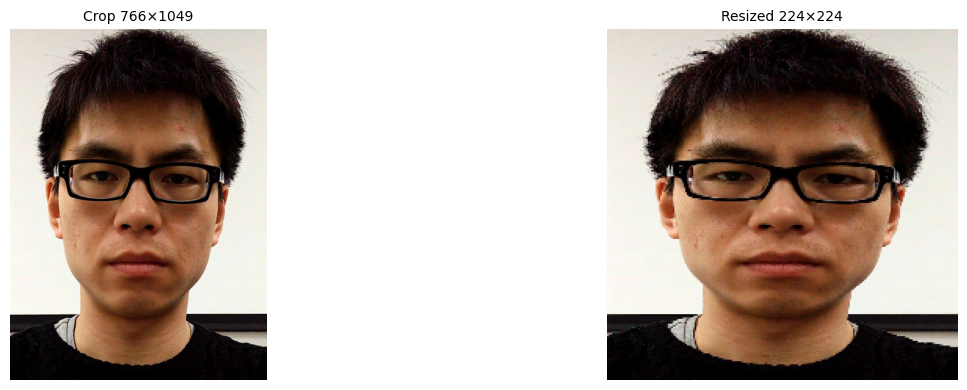

In [9]:
# ── Cell 8: Step 3 — Resize ───────────────────────────────────────────────────
TARGET_SIZE = 224  # 224 for CLIP/ViT-based, 256 for CNN-based

crop = crop_normal.copy()
resized = cv2.resize(crop, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_LINEAR)

print(f"Crop shape:   {crop.shape}")
print(f"Resized shape: {resized.shape}")
show_images([crop, resized], [f"Crop {crop.shape[1]}×{crop.shape[0]}", f"Resized {TARGET_SIZE}×{TARGET_SIZE}"])

# Augmentation

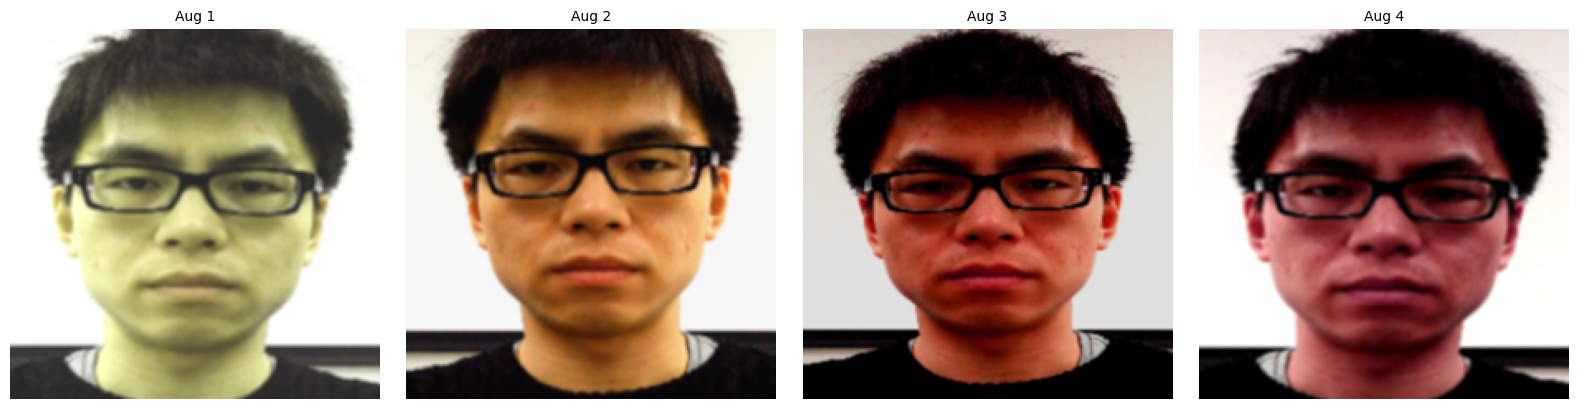

In [10]:
# ── Cell 9: Step 4 — Augmentation (train only) ────────────────────────────────
from torchvision.transforms import functional as F

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.1),         # simulates IR-like conditions
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),  # compression artifact
    transforms.RandomResizedCrop(TARGET_SIZE, scale=(0.85, 1.0)),
])

# Show 4 augmented versions of the same crop
augs = [np.array(train_transform(resized)) for _ in range(4)]
show_images(augs, [f"Aug {i+1}" for i in range(4)], figsize=(16, 4))

# Normalize Tensor

Tensor shape:  torch.Size([3, 224, 224])
Tensor dtype:  torch.float32
Value range:   [-2.118, 2.535]


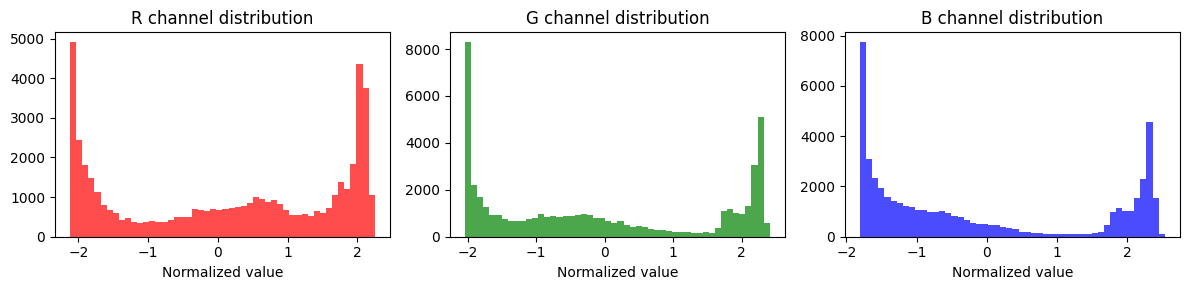

In [11]:
# ── Cell 10: Step 5 — Normalize to tensor ─────────────────────────────────────
# ImageNet mean/std — standard for any pretrained backbone (CLIP, ViT, ResNet...)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

to_tensor = transforms.Compose([
    transforms.ToTensor(),                    # HWC uint8 → CHW float32 in [0,1]
    transforms.Normalize(mean=MEAN, std=STD)  # per-channel standardize
])

# resized is BGR numpy → convert to RGB first
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
tensor = to_tensor(resized_rgb)

print(f"Tensor shape:  {tensor.shape}")   # [3, 224, 224]
print(f"Tensor dtype:  {tensor.dtype}")   # torch.float32
print(f"Value range:   [{tensor.min():.3f}, {tensor.max():.3f}]")  # roughly [-2, 2]

# Visualize what normalization does to pixel values
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
channel_names = ['R', 'G', 'B']
for i, (ax, name) in enumerate(zip(axes, channel_names)):
    ax.hist(tensor[i].numpy().ravel(), bins=50, color=['r','g','b'][i], alpha=0.7)
    ax.set_title(f"{name} channel distribution")
    ax.set_xlabel("Normalized value")
plt.tight_layout()
plt.show()